In [34]:
import numpy as np
from tensorflow.keras.models import Sequential

# RNN layer
from tensorflow.keras.layers import SimpleRNN,LSTM

# Fully connected output layer
from tensorflow.keras.layers import Dense

# Converts word IDs into dense vectors
from tensorflow.keras.layers import Embedding

# Converts text into sequences of numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# Makes all sequences the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [35]:
english_texts = [
    "the weather is nice today",
    "i need water",
    "where is station",
    "hello",
    "good morning",
    "good evening",
    "i am hungry",
    "i love you",
    "the cat is sleeping",
    "learning AI is fun"
]
 
german_texts = [
    "das wetter ist heute schön",
    "ich brauche wasser",
    "wo ist der bahnhof",
    "hallo",
    "guten morgen",
    "guten abend",
    "ich habe hunger",
    "ich liebe dich",
    "die katze schläft",
    "ki lernen macht spaß"
]
 

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([
    1,1,1,1,1,
    1,1,1,1,1,
    0,0,0,0,0,
    0,0,0,0,0
])

In [36]:

# Create tokenizer objects
tokenizer1 = Tokenizer()
tokenizer2 = Tokenizer()

# Learn all unique words from the dataset
tokenizer1.fit_on_texts(english_texts)
tokenizer2.fit_on_texts(german_texts)

# Create dictionaries
# word -> integer ID

print("English Word Index:")
print(tokenizer1.word_index)

print("\nGerman Word Index:")
print(tokenizer2.word_index)

# Convert sentences into sequences
sequences1 = tokenizer1.texts_to_sequences(english_texts)

sequences2 = tokenizer2.texts_to_sequences(german_texts)

print("\nEnglish Sequences:")
print(sequences1)

print("\nGerman Sequences:")
print(sequences2)

# Example:
# "I love this movie"
# may become
# [3, 4, 1, 2]

English Word Index:
{'is': 1, 'i': 2, 'the': 3, 'good': 4, 'weather': 5, 'nice': 6, 'today': 7, 'need': 8, 'water': 9, 'where': 10, 'station': 11, 'hello': 12, 'morning': 13, 'evening': 14, 'am': 15, 'hungry': 16, 'love': 17, 'you': 18, 'cat': 19, 'sleeping': 20, 'learning': 21, 'ai': 22, 'fun': 23}

German Word Index:
{'ich': 1, 'ist': 2, 'guten': 3, 'das': 4, 'wetter': 5, 'heute': 6, 'schön': 7, 'brauche': 8, 'wasser': 9, 'wo': 10, 'der': 11, 'bahnhof': 12, 'hallo': 13, 'morgen': 14, 'abend': 15, 'habe': 16, 'hunger': 17, 'liebe': 18, 'dich': 19, 'die': 20, 'katze': 21, 'schläft': 22, 'ki': 23, 'lernen': 24, 'macht': 25, 'spaß': 26}

English Sequences:
[[3, 5, 1, 6, 7], [2, 8, 9], [10, 1, 11], [12], [4, 13], [4, 14], [2, 15, 16], [2, 17, 18], [3, 19, 1, 20], [21, 22, 1, 23]]

German Sequences:
[[4, 5, 2, 6, 7], [1, 8, 9], [10, 2, 11, 12], [13], [3, 14], [3, 15], [1, 16, 17], [1, 18, 19], [20, 21, 22], [23, 24, 25, 26]]


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, TimeDistributed
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input

max_len = 5

X1 = pad_sequences(
    sequences1,
    maxlen=max_len
)

print("\nEnglish Padded Sequences:")
print(X1)

X2 = pad_sequences(
    sequences2,
    maxlen=max_len
)

print("\nGerman Padded Sequences:")
print(X2)

model1 = Sequential()


model1 = Sequential()

model1.add(
    Input(shape=(max_len,))
)

model1.add(
    Embedding(
        input_dim=len(tokenizer1.word_index) + 1,
        output_dim=16
    )
)

model1.add(
    SimpleRNN(
        64,
        return_sequences=True
    )
)

model1.add(
    TimeDistributed(
        Dense(
            len(tokenizer2.word_index) + 1,
            activation='softmax'
        )
    )
)

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()


English Padded Sequences:
[[ 3  5  1  6  7]
 [ 0  0  2  8  9]
 [ 0  0 10  1 11]
 [ 0  0  0  0 12]
 [ 0  0  0  4 13]
 [ 0  0  0  4 14]
 [ 0  0  2 15 16]
 [ 0  0  2 17 18]
 [ 0  3 19  1 20]
 [ 0 21 22  1 23]]

German Padded Sequences:
[[ 4  5  2  6  7]
 [ 0  0  1  8  9]
 [ 0 10  2 11 12]
 [ 0  0  0  0 13]
 [ 0  0  0  3 14]
 [ 0  0  0  3 15]
 [ 0  0  1 16 17]
 [ 0  0  1 18 19]
 [ 0  0 20 21 22]
 [ 0 23 24 25 26]]


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 5, 16)          │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 5, 64)          │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 27)          │         1,755 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,323 (28.61 KB)

 Trainable params: 7,323 (28.61 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, TimeDistributed, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 5

X1 = pad_sequences(sequences1, maxlen=max_len)
X2 = pad_sequences(sequences2, maxlen=max_len)

y = np.expand_dims(X2, axis=-1)

# =========================
# RNN MODEL
# =========================

rnn_model = Sequential()

rnn_model.add(Input(shape=(max_len,)))

rnn_model.add(
    Embedding(
        input_dim=len(tokenizer1.word_index) + 1,
        output_dim=64
    )
)

rnn_model.add(
    SimpleRNN(
        64,
        return_sequences=True
    )
)

rnn_model.add(
    TimeDistributed(
        Dense(
            len(tokenizer2.word_index) + 1,
            activation='softmax'
        )
    )
)

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

rnn_model.summary()

rnn_history = rnn_model.fit(
    X1,
    y,
    epochs=300,
    verbose=1
)


# =========================
# LSTM MODEL
# =========================

lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(
    Embedding(
        input_dim=len(tokenizer1.word_index) + 1,
        output_dim=64
    )
)

lstm_model.add(
    LSTM(
        64,
        return_sequences=True
    )
)

lstm_model.add(
    TimeDistributed(
        Dense(
            len(tokenizer2.word_index) + 1,
            activation='softmax'
        )
    )
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X1,
    y,
    epochs=300,
    verbose=1
)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 5, 64)          │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 5, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 27)          │         1,755 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,547 (45.11 KB)

 Trainable params: 11,547 (45.11 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 5, 64)          │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 5, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 27)          │         1,755 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,315 (141.86 KB)

 Trainable params: 36,315 (141.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0400 - loss: 3.2945
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4400 - loss: 3.2866
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4200 - loss: 3.2787
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4200 - loss: 3.2707
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4200 - loss: 3.2624
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4000 - loss: 3.2539
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4000 - loss: 3.2449
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4000 - loss: 3.2355
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4000 - loss: 3.2254
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4000 - loss: 3.2147
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4000 - loss: 3.2032
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4000 - lo

In [39]:
# Fit RNN model
rnn_history = rnn_model.fit(
    X1,
    y,
    epochs=300,
    verbose=1
)

# Fit LSTM model
lstm_history = lstm_model.fit(
    X1,
    y,
    epochs=300,
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9800 - loss: 0.0700
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9800 - loss: 0.0700
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0699
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9800 - loss: 0.0698
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0697
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9800 - loss: 0.0696
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0695
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0695
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0694
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0693
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - loss: 0.0692
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9800 - lo

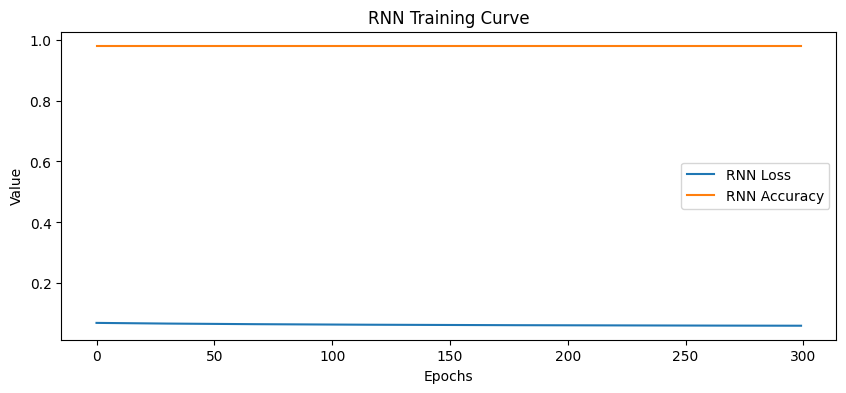

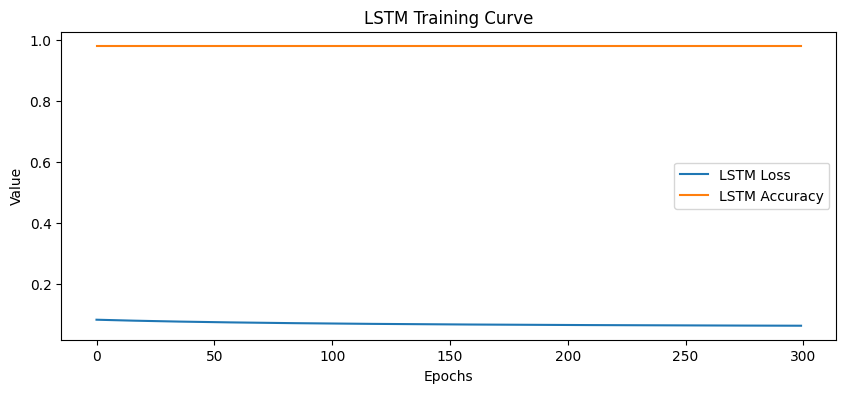

In [41]:
import matplotlib.pyplot as plt

# =========================
# RNN Plot
# =========================

plt.figure(figsize=(10,4))

plt.plot(
    rnn_history.history['loss'],
    label='RNN Loss'
)

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN Accuracy'
)

plt.title("RNN Training Curve")

plt.xlabel("Epochs")
plt.ylabel("Value")

plt.legend()

plt.show()


# =========================
# LSTM Plot
# =========================

plt.figure(figsize=(10,4))

plt.plot(
    lstm_history.history['loss'],
    label='LSTM Loss'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM Accuracy'
)

plt.title("LSTM Training Curve")

plt.xlabel("Epochs")
plt.ylabel("Value")

plt.legend()

plt.show()